<a href="https://colab.research.google.com/github/hkrishnanrt/DSA-Activities/blob/main/Exit_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Loading and merging the files

In [2]:
data=pd.read_excel('/content/partpdf_1763620928546_netflix_titles.xlsx')
data

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id
0,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0
1,94,NaN,Movie,Jandino: Whatever it Takes,2016-09-09 00:00:00,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401.0
2,NaN,1,TV Show,Transformers Prime,2018-09-08 00:00:00,2013.0,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439.0
3,NaN,1,TV Show,Transformers: Robots in Disguise,2018-09-08 00:00:00,2016.0,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654.0
4,99,NaN,Movie,#realityhigh,2017-09-08 00:00:00,2017.0,TV-14,When nerdy high schooler Dani finally attracts...,80125979.0
...,...,...,...,...,...,...,...,...,...
6231,NaN,13,TV Show,Red vs. Blue,NaN,2015.0,NR,"This parody of first-person shooter games, mil...",80000063.0
6232,NaN,4,TV Show,Maron,NaN,2016.0,TV-MA,"Marc Maron stars as Marc Maron, who interviews...",70286564.0
6233,60,NaN,Movie,Little Baby Bum: Nursery Rhyme Friends,NaN,2016.0,NaN,Nursery rhymes and original music for children...,80116008.0
6234,NaN,2,TV Show,A Young Doctor's Notebook and Other Stories,NaN,2013.0,TV-MA,"Set during the Russian Revolution, this comic ...",70281022.0


In [3]:
# Load all sheets
file_path = "/content/partpdf_1763620928546_netflix_titles.xlsx"

sheets = pd.read_excel(file_path, sheet_name=None)


main_df = sheets['netflix_titles']
cast_df = sheets['netflix_titles_directors']
crew_df = sheets['netflix_titles_cast']
genres_df = sheets['netflix_titles_countries']
countries_df = sheets['netflix_titles_category']

# Use LEFT JOIN to keep all titles, even if no matching info in other tables
master_df = main_df \
    .merge(cast_df, how='left', on='show_id') \
    .merge(crew_df, how='left', on='show_id') \
    .merge(genres_df, how='left', on='show_id') \
    .merge(countries_df, how='left', on='show_id')

For merging we used the left join.
The main sheet, `netflix_titles`, contains the primary list of all Netflix titles. The other sheets (like cast, crew, genre, and country) provide optional, supplementary information about each title.

Using a left join ensures that all titles from the main sheet are included in the resulting master DataFrame, even if some titles do not have corresponding entries in the other sheets.

In [4]:
master_df

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,director,cast,country,listed_in
0,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,Alan Marriott,United States,Children & Family Movies
1,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,Alan Marriott,United States,Comedies
2,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,Alan Marriott,China,Children & Family Movies
3,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,Alan Marriott,China,Comedies
4,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,Alan Marriott,India,Children & Family Movies
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139941,NaN,10,TV Show,Friends,NaN,2003.0,TV-14,This hit sitcom follows the merry misadventure...,70153404.0,NaN,Courteney Cox,United States,TV Comedies
139942,NaN,10,TV Show,Friends,NaN,2003.0,TV-14,This hit sitcom follows the merry misadventure...,70153404.0,NaN,Lisa Kudrow,United States,Classic & Cult TV
139943,NaN,10,TV Show,Friends,NaN,2003.0,TV-14,This hit sitcom follows the merry misadventure...,70153404.0,NaN,Lisa Kudrow,United States,TV Comedies
139944,NaN,10,TV Show,Friends,NaN,2003.0,TV-14,This hit sitcom follows the merry misadventure...,70153404.0,NaN,Matt LeBlanc,United States,Classic & Cult TV


Data Cleaning and Preprocessing

In [9]:
master_df.isna().sum()

,0
type,0
title,0
date_added,159
release_year,0
rating,0
description,0
show_id,0
director,0
cast,0
country,0


In [ ]:
#Drop duration_minutes and duration_seasons
master_df.drop(columns=['duration_minutes','duration_seasons'],inplace=True)

#Replace missing with 'Unknown'
master_df['type'] = master_df['type'].fillna('Unknown').str.title().str.strip()

#drop rows with missing titles
master_df = master_df.dropna(subset=['title'])

#convert to datetime, leave as NaT if missing
master_df['date_added'] = pd.to_datetime(master_df['date_added'], errors='coerce')

#replace missing with 'UNRATED'
master_df['rating'] = master_df['rating'].fillna('UNRATED').str.upper().str.strip()

# 8. description: replace missing with 'No description available'
master_df['description'] = master_df['description'].fillna('No description available').str.strip()

#drop rows with missing show_id
master_df = master_df.dropna(subset=['show_id'])

#director: replace missing with 'Unknown'
master_df['director'] = master_df['director'].fillna('Unknown').str.strip()

#cast: replace missing with 'Unknown'
master_df['cast'] = master_df['cast'].fillna('Unknown').str.strip()

#country: replace missing with 'Unknown'
master_df['country'] = master_df['country'].fillna('Unknown').str.strip()

#listed_in: replace missing with 'Unknown'
master_df['listed_in'] = master_df['listed_in'].fillna('Unknown').str.strip()



For the country column, I chose to fill missing values with the placeholder 'Unknown' instead of dropping rows or attempting imputation.

* Dropping rows with missing country information would result in the loss of potentially valuable data about Netflix titles, which could impact the completeness and representativeness of the dataset.
* Imputation using any guesswork (e.g., inferring from language or cast) could
introduce bias or inaccuracies if not done carefully and with supporting data.
* Consistent & Transparent Replacing missing countries with a clear identifier like 'Unknown' allows for easy filtering or grouping in analysis. It makes the absence of information explicit and maintains a uniform standard across the dataset.


Advanced Data Transformation

In [7]:
import pandas as pd

# Split genre strings by comma, strip whitespace
master_df['listed_in_split'] = master_df['listed_in'].str.split(r',\s*')
# Explode the 'listed_in_split' column to get one genre per row
master_df= master_df.explode('listed_in_split').rename(columns={'listed_in_split': 'category'})

# Preview result
print(master_df[['show_id', 'title', 'category']].head())

      show_id                                    title  \
0  81145628.0  Norm of the North: King Sized Adventure   
1  81145628.0  Norm of the North: King Sized Adventure   
2  81145628.0  Norm of the North: King Sized Adventure   
3  81145628.0  Norm of the North: King Sized Adventure   
4  81145628.0  Norm of the North: King Sized Adventure   

                   category  
0  Children & Family Movies  
1                  Comedies  
2  Children & Family Movies  
3                  Comedies  
4  Children & Family Movies  


Transforming the `listed_in` column so that each row contains only a single genre (category) per show unlocks much richer forms of analysis:

* Frequency Analysis: We can now count how many times each genre appears across the catalog and identify the most popular or saturated genres.
* Trend Analysis: We can look at genre popularity over time, across regions, or by other dimensions (e.g. year added).
* Customer Insights: It's possible to relate individual user preferences with specific genres to improve recommendations.
* Catalog Gaps: We can spot genres that are underrepresented, helping Netflix target content acquisitions or production.

*Previously Difficult or Impossible Analysis:**
- Before exploding, finding the top genres, measuring trends, or segmenting by genre required complex string operations. After exploding, these are simple `groupby` or aggregation queries.
`

EDA

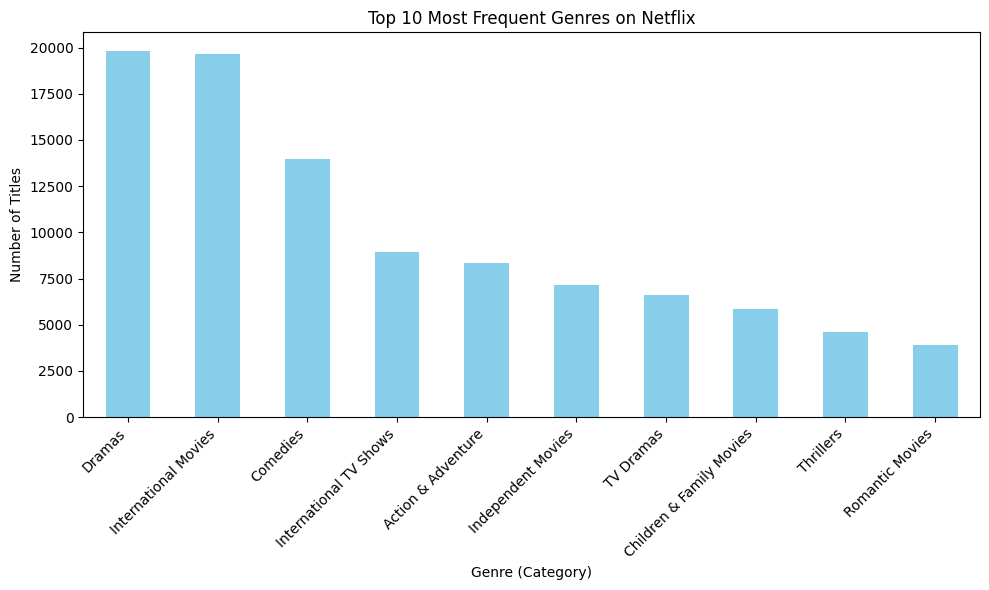

In [8]:
import pandas as pd
import matplotlib.pyplot as plt


# Compute top 10 most frequent genres (categories)
top10 = master_df['category'].value_counts().head(10)

# Create Bar Chart
plt.figure(figsize=(10,6))
top10.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Frequent Genres on Netflix')
plt.xlabel('Genre (Category)')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The bar chart reveals a strong emphasis on global and diverse content, with **"International TV Shows"** and **"Dramas"** among the most common genres. This pattern suggests that Netflix’s content strategy favors a broad international appeal and a focus on serialized storytelling, likely to capture a wide, engaged audience across different markets.

In [11]:
master_df.to_csv('Cleaned.csv')